In [22]:
import pytest
from anymatrix import Anymatrix
import matlab.engine
import statistics
import timeit
import numpy as np

am = Anymatrix()
eng = matlab.engine.start_matlab()
eng.cd(r"C:\Users\propo\OneDrive - University of Leeds\Documents\MATLAB\anymatrix", nargout=1)
eng.anymatrix(nargout=0)
am.anymatrix()

Automatic anymatrix scanning done.
Help on function anymatrix in module anymatrix.main:

anymatrix(self, *varargin)
    ANYMATRIX  Interface for accessing the Anymatrix collections.
    ANYMATRIX is a user interface for the Anymatrix matrix collection.
    It provides commands to list matrices, groups and sets, search for
    matrices by properties, and obtain the matrices by their IDs.

    The interface comes with built-in groups of matrices, but users can
    develop their own groups and make them available to other users.

    The built-in collection contains 7 groups:

    contest  - the CONTEST test matrix toolbox of random matrices
                from networks.
    core     - miscellaneous matrices.
    gallery  - matrices from the MATLAB gallery.
    hadamard - a large collection of (complex) Hadamard matrices.
    matlab   - other MATLAB matrices (not in gallery).
    nessie   - matrices from real-life networks.
    regtools - matrices from regularization problems.

    Anyma

In [33]:
search_query = ["integer", "banded and square", "square and rectangular and scalable", "positive and square or hankel and real", "positive and square or hankel and real or integer"]

python_time = []

for query in search_query:
    times = timeit.repeat(f"am.anymatrix('prop', '{query}')", globals=globals(), repeat=10000, number=1)
    median_time = statistics.median(times)
    python_time.append(median_time)
    
    # Run the same query in MATLAB
    matlab_func = f"@() anymatrix('prop', '{query}')"
    matlab_times = eng.eval(f"timeit({matlab_func})", nargout=1)

print(python_time)

[7.710000136285089e-05, 0.00010869999823626131, 0.00014650000230176374, 0.00017529999968246557, 0.00021190000188653357]


In [70]:

matlab_time = []
for query in search_query:
    matlab_func = f"@() anymatrix('prop', '{query}')"
    matlab_time.append(eng.eval(f"timeit({matlab_func})", nargout=1))
    
print(matlab_time)

[0.00392469185, 0.00433809185, 0.00466019185, 0.00485579185, 0.0044648918499999996]


In [74]:
matlab_time = [0.00132338905, 0.00141728905, 0.001589489, 0.00161008905 ,0.00176758905]

In [87]:
am.anymatrix("matlab/compan", 4)

array([], dtype=float64)

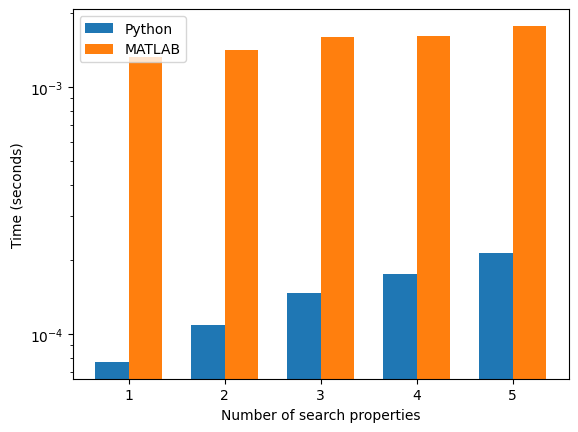

In [86]:
import numpy as np

import matplotlib.pyplot as plt

# Define the number of groups
n_groups = len(search_query)

# Create a figure and a set of subplots
fig, ax = plt.subplots()
ax.set_yscale('log')

# Define the index for the groups
index = np.arange(n_groups)

# Define the bar width
bar_width = 0.35

# Plot the bars
bar1 = plt.bar(index, python_time, bar_width, label='Python')
bar2 = plt.bar(index + bar_width, matlab_time, bar_width, label='MATLAB')

# Add labels, title, and legend
plt.xlabel('Number of search properties')
plt.ylabel('Time (seconds)')

# plt.title('Execution Time for Different Queries')
plt.xticks(index + bar_width / 2, [str(i+1) for i in range(n_groups)])
plt.legend(loc='upper left')
# Show the plot
plt.show()